In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_excel("/content/Advanced_Regression_HousePrice_Dataset_3800.xlsx")

In [8]:
df.shape

(3800, 12)

In [9]:
df.head()

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   property_id       3800 non-null   int64         
 1   sale_date         3800 non-null   datetime64[ns]
 2   area_sqft         3800 non-null   int64         
 3   bedrooms          3800 non-null   int64         
 4   bathrooms         3800 non-null   int64         
 5   location_score    3800 non-null   float64       
 6   property_age      3800 non-null   int64         
 7   distance_city_km  3800 non-null   float64       
 8   near_school       3800 non-null   int64         
 9   near_metro        3800 non-null   int64         
 10  crime_rate_index  3800 non-null   float64       
 11  house_price_inr   3800 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 356.4 KB


In [11]:
df.describe()

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
count,3800.00000,3800,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3.800000e+03
mean,201900.50000,2016-11-27 23:45:13.263158016,1716.925526,3.428158,2.916316,6.502237,22.537105,13.085132,0.548421,0.472895,4.242911,2.071940e+07
min,200001.00000,2010-01-01 00:00:00,500.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.500000,1.506126e+06
25%,200950.75000,2013-06-01 00:00:00,1322.000000,2.000000,2.000000,5.300000,14.000000,8.500000,0.000000,0.000000,2.810000,1.446895e+07
50%,201900.50000,2016-12-01 00:00:00,1700.500000,3.000000,3.000000,6.500000,20.000000,13.000000,1.000000,0.000000,4.220000,1.989180e+07
75%,202850.25000,2020-05-01 00:00:00,2105.000000,4.000000,4.000000,7.700000,29.000000,17.500000,1.000000,1.000000,5.650000,2.596062e+07
max,203800.00000,2023-12-01 00:00:00,3776.000000,7.000000,6.000000,10.000000,80.000000,38.700000,1.000000,1.000000,12.000000,5.930315e+07
std,1097.10984,NaN,582.996559,1.356682,1.133540,1.766945,12.325740,6.537425,0.497715,0.499330,2.045371,8.707465e+06


In [12]:
df["sale_date"] = pd.to_datetime(df["sale_date"])
df["sale_date"].head()

,sale_date
0,2014-01-01
1,2019-12-01
2,2016-10-01
3,2013-03-01
4,2013-07-01


In [13]:
df["Sale_Year"] = df["sale_date"].dt.year
df["Sale_Month"] = df["sale_date"].dt.month
df["Sale_Day"] = df["sale_date"].dt.day
df.head()

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr,Sale_Year,Sale_Month,Sale_Day
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898,2014,1,1
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893,2019,12,1
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242,2016,10,1
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310,2013,3,1
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429,2013,7,1


In [14]:
X = df.drop(
    ["property_id", "sale_date", "house_price_inr"],
    axis=1)
y = df["house_price_inr"]
print("Features")
print(X.head())
print("\nTarget")
print(y.head())

Features
   area_sqft  bedrooms  bathrooms  location_score  property_age  \
0       2181         6          4             8.1            21   
1       2383         5          4             5.3            28   
2       1047         3          3             5.9             7   
3       1753         4          3             7.0            27   
4       1728         4          4            10.0            32   

   distance_city_km  near_school  near_metro  crime_rate_index  Sale_Year  \
0               3.8            0           0              4.84       2014   
1              10.9            1           1              2.89       2019   
2              27.5            0           1              4.04       2016   
3              12.1            0           0              3.28       2013   
4               1.4            0           1              3.84       2013   

   Sale_Month  Sale_Day  
0           1         1  
1          12         1  
2          10         1  
3           3        

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)
print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (3040, 12)
Testing Shape : (760, 12)


In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [18]:
ridge1 = Ridge(alpha=0.1)
ridge1.fit(X_train_scaled, y_train)
ridge_pred1 = ridge1.predict(X_test_scaled)

In [19]:
ridge2 = Ridge(alpha=1)
ridge2.fit(X_train_scaled, y_train)
ridge_pred2 = ridge2.predict(X_test_scaled)

In [20]:
ridge3 = Ridge(alpha=10)
ridge3.fit(X_train_scaled, y_train)
ridge_pred3 = ridge3.predict(X_test_scaled)

In [21]:
results = pd.DataFrame({
    "Alpha":[0.1,1,10],
    "MAE":[
        mean_absolute_error(y_test,ridge_pred1),
        mean_absolute_error(y_test,ridge_pred2),
        mean_absolute_error(y_test,ridge_pred3)
    ],
    "RMSE":[
        np.sqrt(mean_squared_error(y_test,ridge_pred1)),
        np.sqrt(mean_squared_error(y_test,ridge_pred2)),
        np.sqrt(mean_squared_error(y_test,ridge_pred3))
    ],
    "R2 Score":[
        r2_score(y_test,ridge_pred1),
        r2_score(y_test,ridge_pred2),
        r2_score(y_test,ridge_pred3)
    ]
})

results

,Alpha,MAE,RMSE,R2 Score
0,0.1,1.945506e+06,2.539733e+06,0.919908
1,1.0,1.945385e+06,2.539952e+06,0.919894
2,10.0,1.944450e+06,2.542425e+06,0.919738


In [22]:
from sklearn.linear_model import Lasso
lasso1 = Lasso(alpha=0.1)
lasso1.fit(X_train_scaled,y_train)
lasso_pred1 = lasso1.predict(X_test_scaled)

In [23]:
lasso2 = Lasso(alpha=1)
lasso2.fit(X_train_scaled,y_train)
lasso_pred2 = lasso2.predict(X_test_scaled)

In [24]:
lasso3 = Lasso(alpha=10)
lasso3.fit(X_train_scaled,y_train)
lasso_pred3 = lasso3.predict(X_test_scaled)

In [25]:
lasso_results = pd.DataFrame({
    "Alpha":[0.1,1,10],
    "MAE":[
        mean_absolute_error(y_test,lasso_pred1),
        mean_absolute_error(y_test,lasso_pred2),
        mean_absolute_error(y_test,lasso_pred3)
    ],
    "RMSE":[
        np.sqrt(mean_squared_error(y_test,lasso_pred1)),
        np.sqrt(mean_squared_error(y_test,lasso_pred2)),
        np.sqrt(mean_squared_error(y_test,lasso_pred3))
    ],
    "R2 Score":[
        r2_score(y_test,lasso_pred1),
        r2_score(y_test,lasso_pred2),
        r2_score(y_test,lasso_pred3)
    ]
})

lasso_results

,Alpha,MAE,RMSE,R2 Score
0,0.1,1.945520e+06,2.539709e+06,0.919909
1,1.0,1.945520e+06,2.539709e+06,0.919909
2,10.0,1.945520e+06,2.539711e+06,0.919909


In [26]:
coef = pd.DataFrame({
    "Feature":X.columns,
    "Ridge":ridge2.coef_,
    "Lasso":lasso2.coef_
})
coef

,Feature,Ridge,Lasso
0,area_sqft,6.948656e+06,6.956028e+06
1,bedrooms,2.952958e+05,2.891290e+05
2,bathrooms,2.730730e+05,2.731572e+05
3,location_score,3.678705e+06,3.680811e+06
4,property_age,-6.499425e+05,-6.501217e+05
5,distance_city_km,-2.852105e+04,-2.714709e+04
6,near_school,1.572028e+04,1.565291e+04
7,near_metro,5.254642e+04,5.263311e+04
8,crime_rate_index,-1.406921e+05,-1.406249e+05
9,Sale_Year,3.009622e+05,3.011496e+05


In [27]:
from sklearn.model_selection import GridSearchCV
ridge = Ridge()
params = {
    "alpha":[0.01,0.1,1,10,100]
}
grid = GridSearchCV(
    ridge,
    params,
    cv=5,
    scoring="r2"
)
grid.fit(X_train_scaled,y_train)
print("Best Alpha:",grid.best_params_)
print("Best Score:",grid.best_score_)

Best Alpha: {'alpha': 1}
Best Score: 0.9164274888156723


In [28]:
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score

In [29]:
ridge = Ridge(alpha=1)
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42)
scores = cross_val_score(
    ridge,
    X_train_scaled,
    y_train,
    cv=kfold,
    scoring="r2")
print("K-Fold Scores")
print(scores)
print("Average Score:", scores.mean())

K-Fold Scores
[0.91935771 0.90750353 0.91433252 0.92045544 0.91988097]
Average Score: 0.9163060347738922


In [30]:
y_category = pd.qcut(
    y_train,
    q=5,
    labels=False
)
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scores = []
for train_index, test_index in skf.split(X_train_scaled, y_category):

    Xtr = X_train_scaled[train_index]
    Xte = X_train_scaled[test_index]

    ytr = y_train.iloc[train_index]
    yte = y_train.iloc[test_index]

    ridge.fit(Xtr, ytr)

    scores.append(ridge.score(Xte, yte))
print("Stratified K-Fold Scores")
print(scores)
print("Average Score:", np.mean(scores))

Stratified K-Fold Scores
[0.911725819266776, 0.9229260374454987, 0.9177658500239173, 0.9187196926089205, 0.912555802989119]
Average Score: 0.9167386404668463


In [31]:
X_time = X.sort_index()

y_time = y.sort_index()

tscv = TimeSeriesSplit(
    n_splits=5
)

scores = cross_val_score(
    ridge,
    X_time,
    y_time,
    cv=tscv,
    scoring="r2"
)

print("Time Series Scores")

print(scores)

print("Average Score:", scores.mean())

Time Series Scores
[0.91405612 0.92066787 0.9165465  0.90547801 0.92185753]
Average Score: 0.9157212066419156


In [32]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(
    random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [33]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
print("Decision Tree Results")
print("MAE :", mean_absolute_error(y_test, dt_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R² :", r2_score(y_test, dt_pred))

Decision Tree Results
MAE : 2385690.861842105
RMSE : 3277696.3420960573
R² : 0.866601220285162


In [34]:
depth = [3,5,7,10]

for d in depth:

    model = DecisionTreeRegressor(
        max_depth=d,
        random_state=42
    )

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    print("Max Depth :", d)

    print("R² :", r2_score(y_test,pred))

    print("-"*30)

Max Depth : 3
R² : 0.7816024536154864
------------------------------
Max Depth : 5
R² : 0.8834566744111698
------------------------------
Max Depth : 7
R² : 0.904469947709538
------------------------------
Max Depth : 10
R² : 0.8739121489077861
------------------------------


In [35]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42)
rf.fit(X_train,y_train)
rf_pred = rf.predict(X_test)

In [36]:
print("Random Forest Results")
print("MAE :", mean_absolute_error(y_test,rf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test,rf_pred)))
print("R² :", r2_score(y_test,rf_pred))

Random Forest Results
MAE : 1758820.2308026315
RMSE : 2406259.2553653875
R² : 0.9281049055567916


In [37]:
comparison = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest"
    ],

    "MAE":[
        mean_absolute_error(y_test,dt_pred),
        mean_absolute_error(y_test,rf_pred)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test,dt_pred)),
        np.sqrt(mean_squared_error(y_test,rf_pred))
    ],

    "R²":[
        r2_score(y_test,dt_pred),
        r2_score(y_test,rf_pred)
    ]

})

comparison

,Model,MAE,RMSE,R²
0,Decision Tree,2.385691e+06,3.277696e+06,0.866601
1,Random Forest,1.758820e+06,2.406259e+06,0.928105


In [38]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [39]:
svr_linear = SVR(kernel="linear")
svr_linear.fit(X_train_scaled, y_train)
linear_pred = svr_linear.predict(X_test_scaled)

In [40]:
print("Linear SVR")
print("MAE :", mean_absolute_error(y_test, linear_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, linear_pred)))
print("R² :", r2_score(y_test, linear_pred))

Linear SVR
MAE : 6990273.928553913
RMSE : 8982717.415461306
R² : -0.0019127401175407233


In [41]:
svr_rbf = SVR(
    kernel="rbf",
    C=100,
    gamma=0.1
)
svr_rbf.fit(X_train_scaled, y_train)
rbf_pred = svr_rbf.predict(X_test_scaled)

In [42]:
print("RBF SVR")
print("MAE :", mean_absolute_error(y_test, rbf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rbf_pred)))
print("R² :", r2_score(y_test, rbf_pred))

RBF SVR
MAE : 6986109.817998203
RMSE : 8977746.948525067
R² : -0.000804256767496625


In [43]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C":[0.1,1,10,100],
    "gamma":[1,0.1,0.01],
    "kernel":["rbf"]
}

grid = GridSearchCV(
    SVR(),
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters")

print(grid.best_params_)

print("Best Score")

print(grid.best_score_)

Best Parameters
{'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
Best Score
-0.006852666480872416


In [44]:
best_svr = grid.best_estimator_
best_pred = best_svr.predict(X_test_scaled)

In [45]:
print("Best SVR Model")
print("MAE :", mean_absolute_error(y_test, best_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, best_pred)))
print("R² :", r2_score(y_test, best_pred))

Best SVR Model
MAE : 6986109.817998203
RMSE : 8977746.948525067
R² : -0.000804256767496625


In [46]:
comparison = pd.DataFrame({

    "Model":[
        "Linear SVR",
        "RBF SVR"
    ],

    "MAE":[
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, rbf_pred)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, rbf_pred))
    ],

    "R²":[
        r2_score(y_test, linear_pred),
        r2_score(y_test, rbf_pred)
    ]

})

comparison

,Model,MAE,RMSE,R²
0,Linear SVR,6.990274e+06,8.982717e+06,-0.001913
1,RBF SVR,6.986110e+06,8.977747e+06,-0.000804


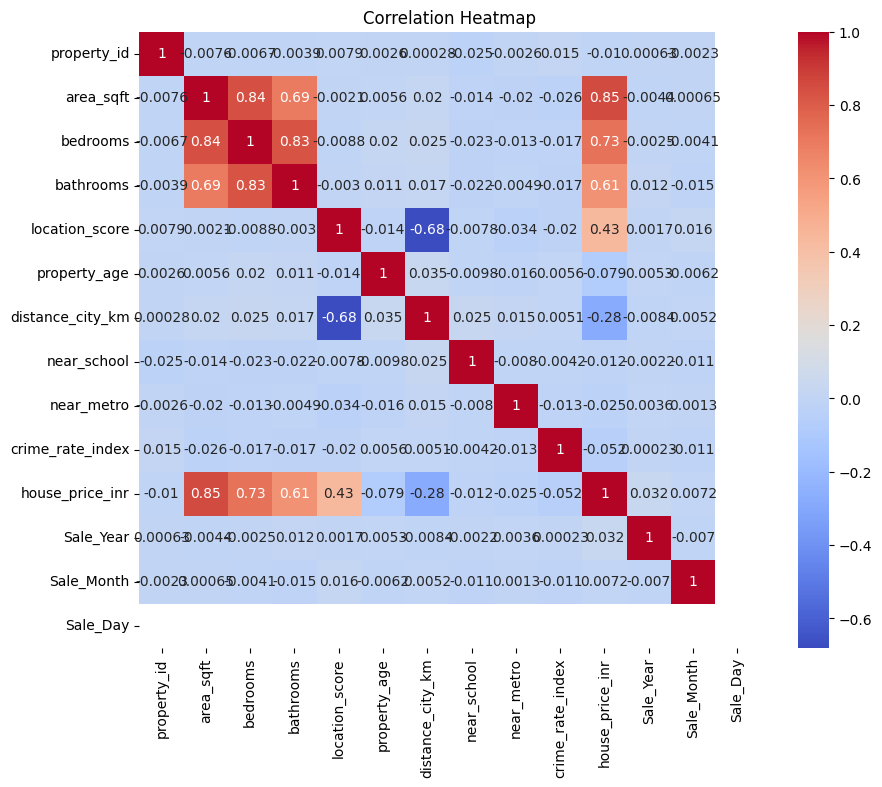

In [47]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

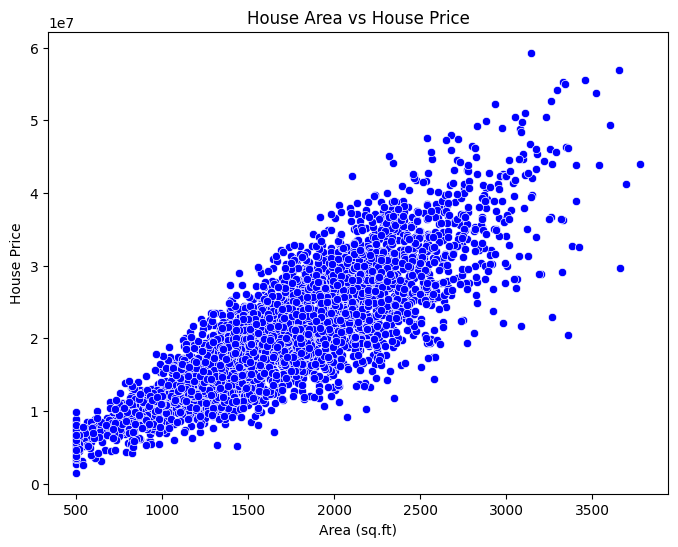

In [48]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["area_sqft"],
    y=df["house_price_inr"],
    color="blue"
)

plt.title("House Area vs House Price")

plt.xlabel("Area (sq.ft)")

plt.ylabel("House Price")

plt.show()

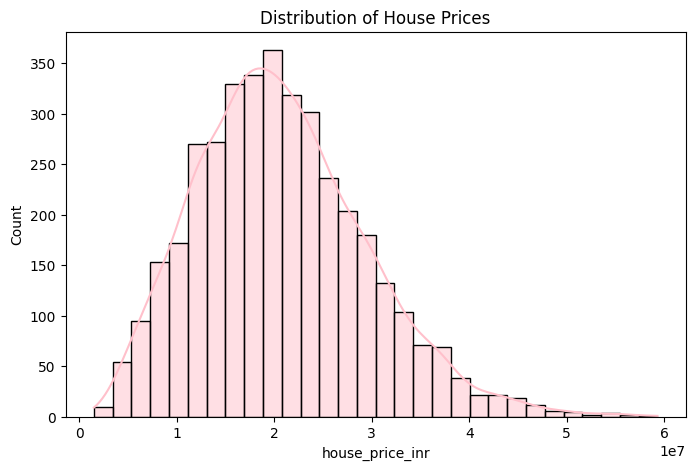

In [49]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["house_price_inr"],
    bins=30,
    kde=True,
    color="pink"
)
plt.title("Distribution of House Prices")
plt.show()

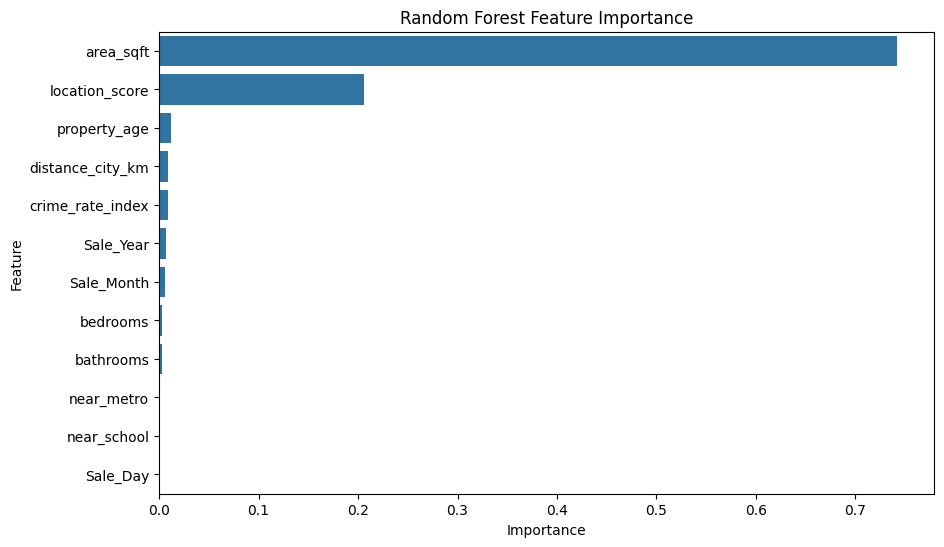

In [50]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_})
importance = importance.sort_values(
    by="Importance",
    ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature")
plt.title("Random Forest Feature Importance")
plt.show()

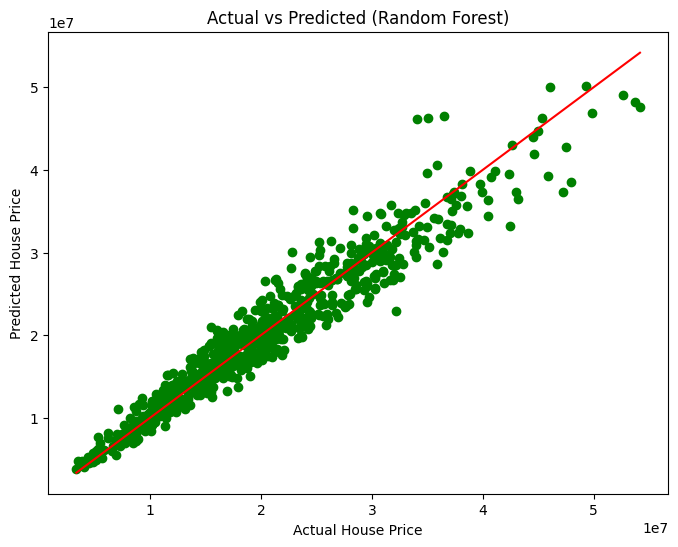

In [51]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred,
    color="green"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

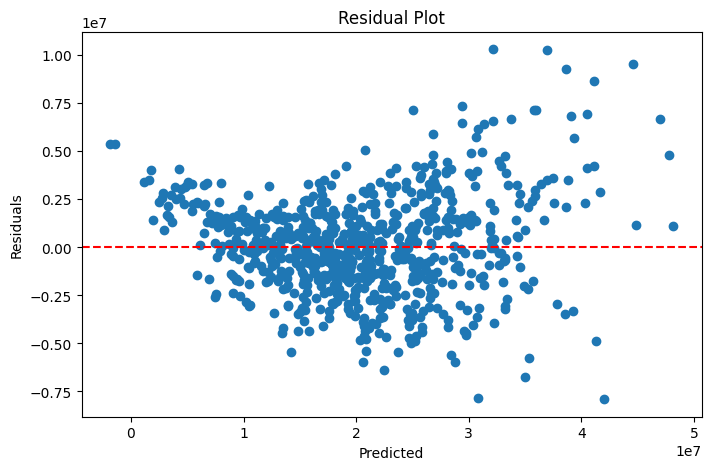

In [52]:
residuals = y_test - ridge_pred2
plt.figure(figsize=(8,5))
plt.scatter(
    ridge_pred2,
    residuals)
plt.axhline(
    y=0,
    color="red",
    linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

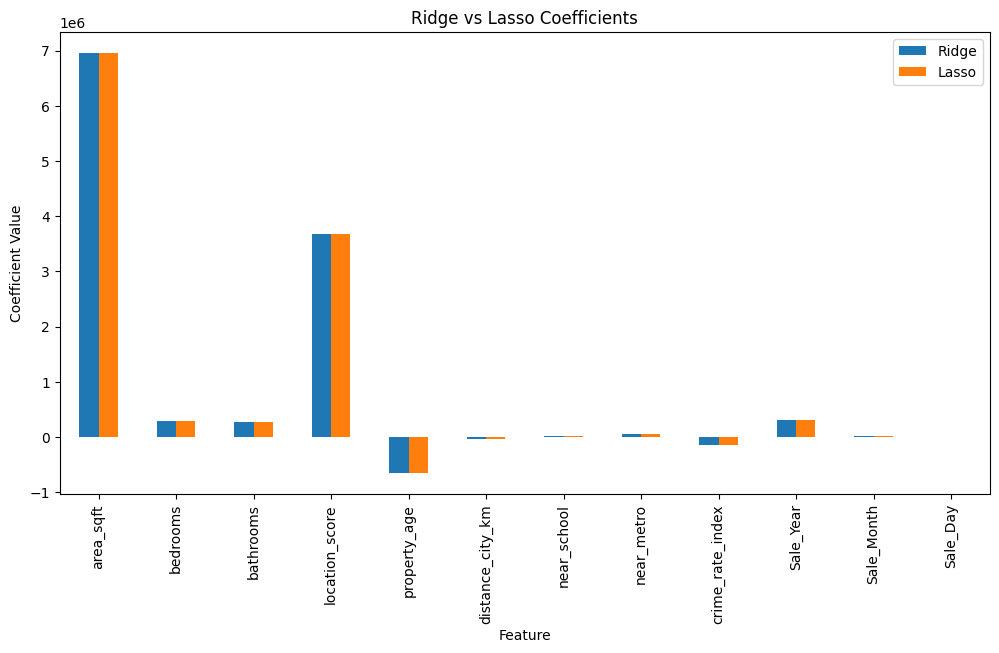

In [53]:
coef = pd.DataFrame({

    "Feature":X.columns,

    "Ridge":ridge2.coef_,

    "Lasso":lasso2.coef_})
coef.set_index("Feature").plot(
    kind="bar",
    figsize=(12,6))
plt.title("Ridge vs Lasso Coefficients")
plt.ylabel("Coefficient Value")
plt.show()

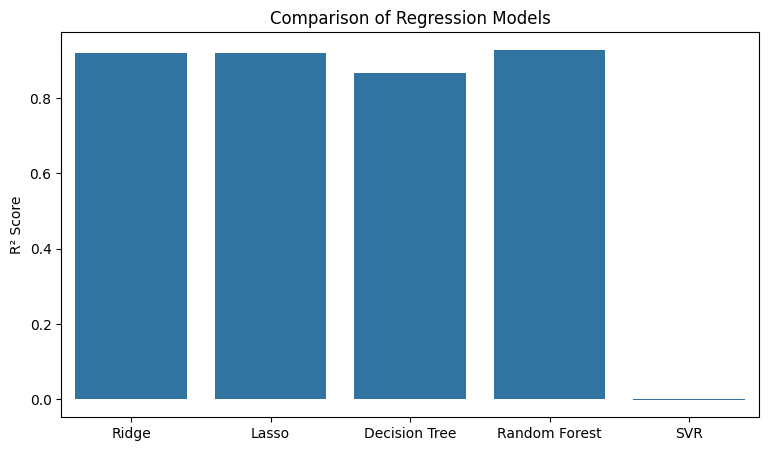

In [55]:
models = [

    "Ridge",

    "Lasso",

    "Decision Tree",

    "Random Forest",

    "SVR"

]

r2_scores = [

    r2_score(y_test, ridge_pred2),

    r2_score(y_test, lasso_pred2),

    r2_score(y_test, dt_pred),

    r2_score(y_test, rf_pred),

    r2_score(y_test, best_pred)

]
plt.figure(figsize=(9,5))
sns.barplot(
    x=models,
    y=r2_scores)
plt.title("Comparison of Regression Models")
plt.ylabel("R² Score")
plt.show()

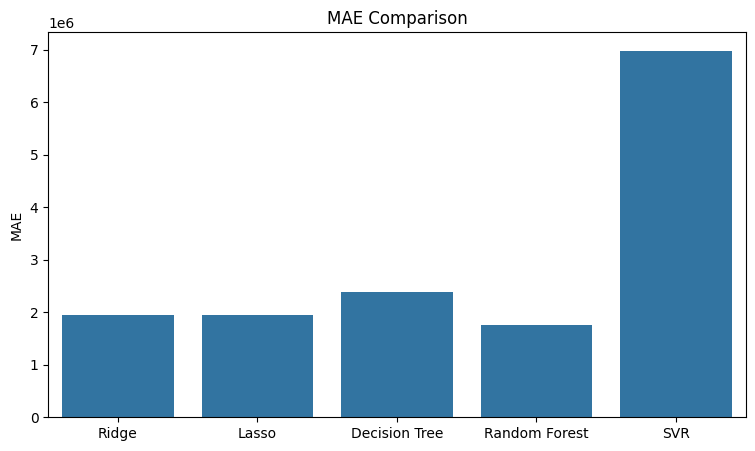

In [57]:
mae_scores = [

    mean_absolute_error(y_test, ridge_pred2),

    mean_absolute_error(y_test, lasso_pred2),

    mean_absolute_error(y_test, dt_pred),

    mean_absolute_error(y_test, rf_pred),

    mean_absolute_error(y_test, best_pred)]
plt.figure(figsize=(9,5))
sns.barplot(
    x=models,
    y=mae_scores)
plt.title("MAE Comparison")
plt.ylabel("MAE")
plt.show()